# Proyek Analisis Data: Klasifikasi Sampah Daur Ulang

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi jumlah gambar pada setiap kategori sampah, dan seberapa besar tingkat ketidakseimbangannya?
- Apakah karakteristik gambar (dimensi dan ukuran file) berbeda antar kategori sehingga perlu perlakuan preprocessing yang berbeda?

## Import Semua Packages/Library yang Digunakan

In [3]:
import warnings
import os
import json
import getpass
import importlib.util
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Data Wrangling

### Gathering Data

#### Set Kredensial Kaggle
Isi `KAGGLE_USERNAME` dan `KAGGLE_KEY` Anda pada cell berikut (disarankan dari environment variable), atau simpan file `kaggle.json` di folder `~/.kaggle/`.

In [4]:
def setup_kaggle_credentials(prompt_if_missing=False, save_to_file=True):
    kaggle_json_path = Path.home() / ".kaggle" / "kaggle.json"
    username = os.getenv("KAGGLE_USERNAME", "")
    key = os.getenv("KAGGLE_KEY", "")

    # Prioritas 1: kredensial dari environment variable
    if username and key:
        source = "environment variable"
    # Prioritas 2: baca dari ~/.kaggle/kaggle.json jika ada
    elif kaggle_json_path.exists():
        with open(kaggle_json_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        username = cfg.get("username", "")
        key = cfg.get("key", "")
        source = "~/.kaggle/kaggle.json"
    else:
        source = "belum ada"

    # Prioritas 3: input manual (opsional)
    if prompt_if_missing and (not username or not key):
        print("Masukkan kredensial Kaggle (API Token).")
        print("Bisa didapat dari: Kaggle > Account > Create New API Token")
        username = input("Kaggle Username: ").strip()
        key = getpass.getpass("Kaggle Key: ").strip()
        source = "input manual"

    if username and key:
        os.environ["KAGGLE_USERNAME"] = username
        os.environ["KAGGLE_KEY"] = key

        if save_to_file:
            kaggle_json_path.parent.mkdir(parents=True, exist_ok=True)
            with open(kaggle_json_path, "w", encoding="utf-8") as f:
                json.dump({"username": username, "key": key}, f)
            print(f"kaggle.json tersimpan di: {kaggle_json_path}")

        print(f"Kredensial Kaggle aktif (sumber: {source}).")
        return True

    print("Kredensial Kaggle belum tersedia. Download otomatis dari Kaggle mungkin gagal.")
    print("Set environment variable KAGGLE_USERNAME & KAGGLE_KEY jika ingin download otomatis.")
    return False

kaggle_ready = setup_kaggle_credentials(prompt_if_missing=False, save_to_file=True)
print("KAGGLE_USERNAME aktif:", bool(os.getenv("KAGGLE_USERNAME")))
print("KAGGLE_KEY aktif:", bool(os.getenv("KAGGLE_KEY")))

Kredensial Kaggle belum tersedia. Download otomatis dari Kaggle mungkin gagal.
Set environment variable KAGGLE_USERNAME & KAGGLE_KEY jika ingin download otomatis.
KAGGLE_USERNAME aktif: False
KAGGLE_KEY aktif: False


In [5]:
def ensure_package(package_name: str):
    if importlib.util.find_spec(package_name) is None:
        print(f"Menginstal package: {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

def resolve_dataset_root(base_path: Path) -> Path | None:
    """Cari root folder dataset yang berisi subfolder kelas gambar."""
    if not base_path.exists() or not base_path.is_dir():
        return None

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    # Beberapa arsip membungkus data di folder DATASETS/dataset/data
    top_dirs = [d for d in base_path.iterdir() if d.is_dir()]
    if len(top_dirs) == 1 and top_dirs[0].name.lower() in {"datasets", "dataset", "data"}:
        candidate = top_dirs[0]
    else:
        candidate = base_path

    class_dirs = [d for d in candidate.iterdir() if d.is_dir()]
    if not class_dirs:
        return None

    has_images = False
    for class_dir in class_dirs:
        if any(p.suffix.lower() in image_exts for p in class_dir.rglob("*")):
            has_images = True
            break

    return candidate if has_images else None

# 1) Coba unduh dataset dari Kaggle secara otomatis (kagglehub).
# 2) Jika gagal, coba via Kaggle API resmi.
# 3) Jika tetap gagal, coba deteksi folder lokal secara otomatis.
DATASET_SLUG = "fathurrahmanalfarizy/sampah-daur-ulang"
AUTO_DOWNLOAD_DIR = Path("./data_kaggle")
FALLBACK_LOCAL_DIRS = [
    Path("./sampah-daur-ulang"),
    Path("./dataset"),
    Path("./data"),
]

dataset_path = None
download_error_messages = []

# Metode A: kagglehub
try:
    ensure_package("kagglehub")
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print(f"Dataset berhasil diunduh via kagglehub ke: {dataset_path}")
except Exception as err:
    download_error_messages.append(f"kagglehub: {err}")

# Metode B: Kaggle API resmi
if dataset_path is None:
    try:
        ensure_package("kaggle")
        from kaggle.api.kaggle_api_extended import KaggleApi

        AUTO_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(DATASET_SLUG, path=str(AUTO_DOWNLOAD_DIR), unzip=True)
        dataset_path = AUTO_DOWNLOAD_DIR
        print(f"Dataset berhasil diunduh via Kaggle API ke: {dataset_path}")
    except Exception as err:
        download_error_messages.append(f"kaggle API: {err}")

# Metode C: auto-detect folder lokal
root_dir = None
if dataset_path is not None:
    root_dir = resolve_dataset_root(dataset_path)

if root_dir is None:
    for local_dir in FALLBACK_LOCAL_DIRS:
        detected = resolve_dataset_root(local_dir)
        if detected is not None:
            root_dir = detected
            print(f"Dataset ditemukan dari folder lokal: {root_dir.resolve()}")
            break

if root_dir is None:
    checked_dirs = "\n- ".join(str(p.resolve()) for p in FALLBACK_LOCAL_DIRS)
    error_text = "\n- ".join(download_error_messages) if download_error_messages else "(tidak ada detail error)"
    raise FileNotFoundError(
        "Dataset belum ditemukan.\n"
        "Silakan lakukan salah satu opsi berikut:\n"
        "1) Jalankan cell kredensial Kaggle dengan API token valid\n"
        "2) Ekstrak dataset manual ke salah satu folder berikut:\n"
        f"- {checked_dirs}\n\n"
        f"Detail error unduh otomatis:\n- {error_text}"
    )

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
records = []

class_dirs = [d for d in root_dir.iterdir() if d.is_dir()]
if not class_dirs:
    raise ValueError("Tidak ada folder kelas yang ditemukan pada dataset.")

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in image_exts:
            records.append(
                {
                    "file_path": str(img_path.resolve()),
                    "class_label": class_dir.name,
                    "file_name": img_path.name,
                    "file_ext": img_path.suffix.lower(),
                }
            )

raw_df = pd.DataFrame(records)

print(f"Jumlah baris metadata mentah: {len(raw_df):,}")
print(f"Jumlah kelas: {raw_df['class_label'].nunique()}")
raw_df.head()

Resuming download from 71303168 bytes (31988670 bytes left)...
Resuming download to C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\5.archive (71303168/103291838) bytes left.


100%|██████████| 98.5M/98.5M [00:18<00:00, 1.75MB/s]

Extracting files...


Dataset berhasil diunduh via kagglehub ke: C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5
Jumlah baris metadata mentah: 7,014
Jumlah kelas: 6


,file_path,class_label,file_name,file_ext
0,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg
1,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg
2,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg
3,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg
4,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg


**Insight:**
- Di tahap ini, data gambar sudah berhasil dibaca per kategori, jadi kita bisa lanjut hitung jumlah gambar di tiap kelas.
- Data ini juga sudah siap dipakai untuk melihat apakah ukuran dan dimensi gambar antar kategori berbeda atau tidak.

### Assessing Data

In [6]:
print("=== Struktur Data ===")
raw_df.info()

print("\n=== Missing Values ===")
print(raw_df.isna().sum())

print("\n=== Duplikasi ===")
print(f"Duplikasi file_path: {raw_df.duplicated(subset=['file_path']).sum()}")
print(f"Duplikasi file_name dalam kelas sama: {raw_df.duplicated(subset=['class_label', 'file_name']).sum()}")

print("\n=== Distribusi Kelas ===")
class_dist = (
    raw_df["class_label"]
    .value_counts()
    .rename_axis("class_label")
    .reset_index(name="n_images")
)
class_dist["pct"] = (class_dist["n_images"] / class_dist["n_images"].sum() * 100).round(2)
print(class_dist)

print("\n=== Distribusi Ekstensi File ===")
print(raw_df["file_ext"].value_counts())

=== Struktur Data ===
<class 'pandas.DataFrame'>
RangeIndex: 7014 entries, 0 to 7013
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   file_path    7014 non-null   str  
 1   class_label  7014 non-null   str  
 2   file_name    7014 non-null   str  
 3   file_ext     7014 non-null   str  
dtypes: str(4)
memory usage: 219.3 KB

=== Missing Values ===
file_path      0
class_label    0
file_name      0
file_ext       0
dtype: int64

=== Duplikasi ===
Duplikasi file_path: 0
Duplikasi file_name dalam kelas sama: 0

=== Distribusi Kelas ===
  class_label  n_images    pct
0      Kertas      1807  25.76
1     Plastik      1257  17.92
2       Logam      1210  17.25
3        Kaca      1110  15.83
4      Residu      1006  14.34
5      Kardus       624   8.90

=== Distribusi Ekstensi File ===
file_ext
.jpg    7014
Name: count, dtype: int64


**Insight:**
- Dari pengecekan awal, kelihatan kalau jumlah gambar tiap kategori belum seimbang.
- Informasi ini penting supaya kita tahu kelas mana yang terlalu banyak dan mana yang masih kurang datanya.

### Cleaning Data

In [7]:
df = raw_df.copy()

# Standarisasi label kelas
df["class_label"] = df["class_label"].astype(str).str.strip().str.title()

# Hapus duplikasi dan nilai kosong
df = df.drop_duplicates(subset=["file_path"])
df = df.dropna(subset=["file_path", "class_label", "file_name", "file_ext"])

# Validasi file gambar sambil ekstrak metadata
clean_records = []
corrupted_files = []

for row in df.itertuples(index=False):
    path = Path(row.file_path)
    try:
        if not path.exists():
            corrupted_files.append(row.file_path)
            continue

        file_size_kb = path.stat().st_size / 1024
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        clean_records.append(
            {
                "file_path": row.file_path,
                "class_label": row.class_label,
                "file_name": row.file_name,
                "file_ext": row.file_ext,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 4) if height else np.nan,
                "pixels": width * height,
                "file_size_kb": round(file_size_kb, 2),
                "color_mode": mode,
            }
        )
    except Exception:
        corrupted_files.append(row.file_path)

clean_df = pd.DataFrame(clean_records)
clean_df = clean_df.dropna(subset=["width", "height", "aspect_ratio", "file_size_kb"])
clean_df = clean_df[(clean_df["width"] > 0) & (clean_df["height"] > 0)]

output_path = Path("clean_sampah_metadata.csv")
clean_df.to_csv(output_path, index=False)

print(f"Jumlah data setelah cleaning: {len(clean_df):,}")
print(f"File korup/tidak valid: {len(corrupted_files):,}")
print(f"Metadata bersih disimpan ke: {output_path.resolve()}")
clean_df.head()

Jumlah data setelah cleaning: 7,014
File korup/tidak valid: 0
Metadata bersih disimpan ke: D:\KULIAHHHH\SEMESTER 6 (DBS DICODING)\Wranglingling\clean_sampah_metadata.csv


,file_path,class_label,file_name,file_ext,width,height,aspect_ratio,pixels,file_size_kb,color_mode
0,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg,225,225,1.0000,50625,2.60,RGB
1,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg,225,225,1.0000,50625,4.86,RGB
2,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg,225,225,1.0000,50625,2.65,RGB
3,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg,183,275,0.6655,50325,3.83,RGB
4,C:\Users\THINKPAD\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg,194,259,0.7490,50246,3.16,RGB


**Insight:**
- Setelah cleaning, data jadi lebih rapi karena file duplikat, data kosong, dan gambar rusak sudah disaring.
- Sekarang perbandingan dimensi dan ukuran file antar kategori jadi lebih aman dan lebih bisa dipercaya.

## Exploratory Data Analysis (EDA)

### Explore Struktur, Distribusi Kelas, dan Karakteristik Gambar

Ukuran data bersih: (7014, 10)

Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
width,7014.0,288.384232,222.587257,42.0000,225.00,243.000,275.0000,6.270000e+03
height,7014.0,243.605503,190.454418,42.0000,183.00,220.000,225.0000,5.625000e+03
aspect_ratio,7014.0,1.242757,0.455802,0.2181,1.00,1.093,1.5027,6.465900e+00
pixels,7014.0,106892.276447,547708.913246,1764.0000,50325.00,50416.000,50625.0000,2.552517e+07
file_size_kb,7014.0,14.620194,64.374036,0.7700,4.04,6.375,10.3475,2.134540e+03


,n_images,avg_width,avg_height,median_file_size_kb,pct
class_label,,,,,
Kertas,1807,248.676812,206.229109,7.400,25.76
Plastik,1257,272.736675,217.804296,7.680,17.92
Logam,1210,243.299174,210.533058,6.185,17.25
Kaca,1110,228.941441,220.360360,5.430,15.83
Residu,1006,524.835984,431.374751,8.055,14.34
Kardus,624,246.852564,206.578526,4.990,8.90


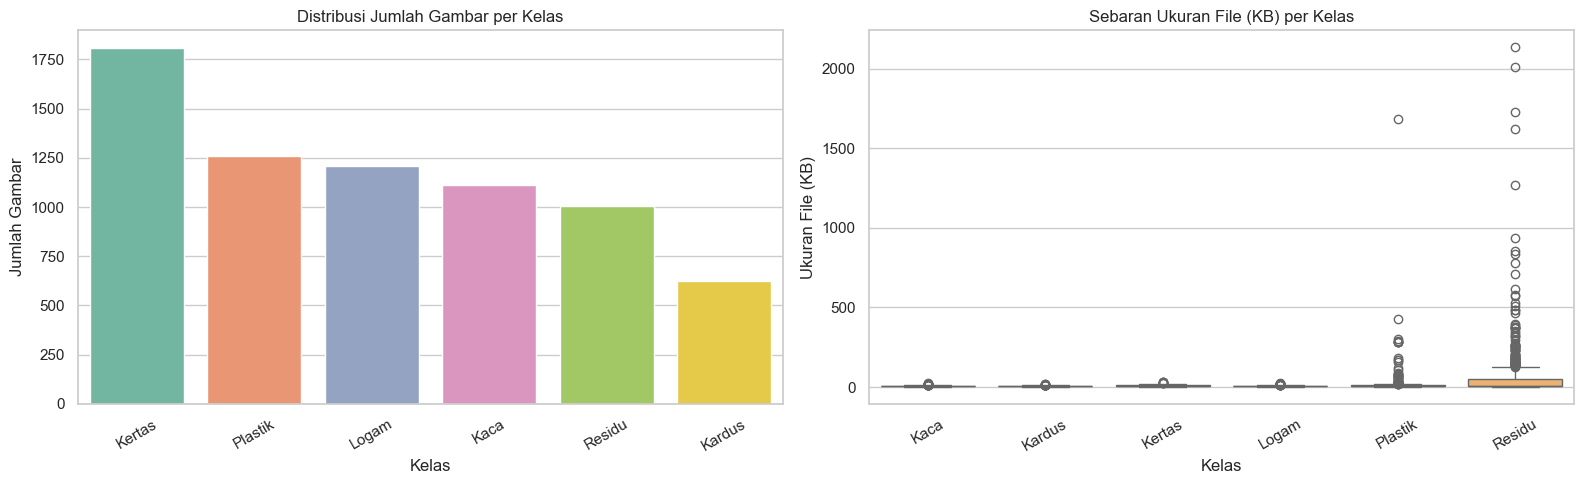

In [8]:
print("Ukuran data bersih:", clean_df.shape)

print("\nStatistik numerik:")
display(clean_df[["width", "height", "aspect_ratio", "pixels", "file_size_kb"]].describe().T)

class_summary = (
    clean_df.groupby("class_label")
    .agg(
        n_images=("file_name", "count"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        median_file_size_kb=("file_size_kb", "median"),
    )
    .sort_values("n_images", ascending=False)
)

class_summary["pct"] = (class_summary["n_images"] / class_summary["n_images"].sum() * 100).round(2)
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=clean_df,
    x="class_label",
    order=clean_df["class_label"].value_counts().index,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Distribusi Jumlah Gambar per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Gambar")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=clean_df, x="class_label", y="file_size_kb", palette="Set3", ax=axes[1])
axes[1].set_title("Sebaran Ukuran File (KB) per Kelas")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Ukuran File (KB)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Insight:**
- EDA awal nunjukin dua hal penting: jumlah data antar kelas belum rata, dan karakteristik gambarnya juga beda-beda.
- Ini jadi dasar untuk menjawab pertanyaan bisnis tentang ketidakseimbangan data dan kebutuhan preprocessing.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi jumlah gambar per kategori dan tingkat ketidakseimbangannya?

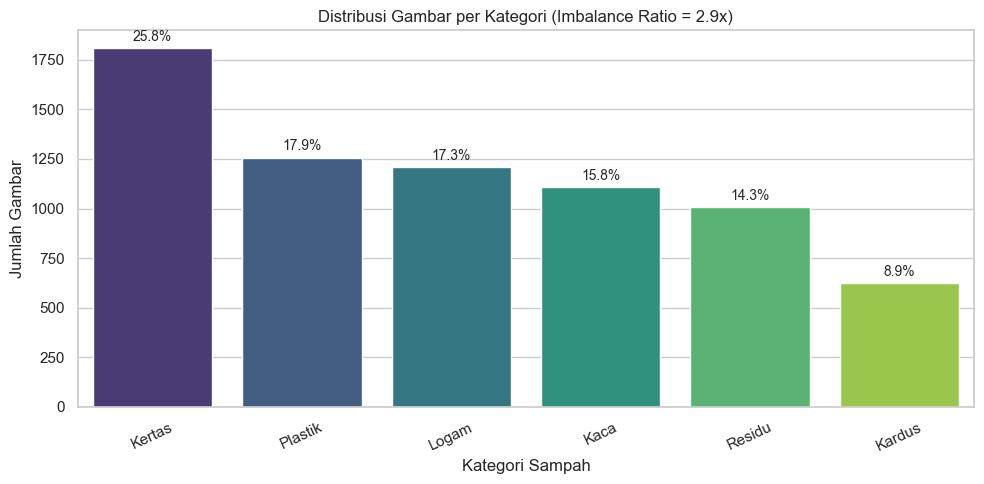

Ringkasan ketidakseimbangan kelas:
- Kelas mayoritas : Kertas (1807 gambar)
- Kelas minoritas : Kardus (624 gambar)
- Selisih jumlah  : 1183 gambar
- Imbalance ratio : 2.9x


,class_label,n_images,pct
0,Kertas,1807,25.76
1,Plastik,1257,17.92
2,Logam,1210,17.25
3,Kaca,1110,15.83
4,Residu,1006,14.34
5,Kardus,624,8.90


In [10]:
q1_dist = (
    clean_df["class_label"]
    .value_counts()
    .rename_axis("class_label")
    .reset_index(name="n_images")
)
q1_dist["pct"] = q1_dist["n_images"] / q1_dist["n_images"].sum() * 100

max_count = q1_dist["n_images"].max()
min_count = q1_dist["n_images"].min()
imbalance_ratio = round(max_count / min_count, 2)
majority_class = q1_dist.loc[q1_dist["n_images"].idxmax(), "class_label"]
minority_class = q1_dist.loc[q1_dist["n_images"].idxmin(), "class_label"]
count_gap = int(max_count - min_count)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=q1_dist, x="class_label", y="n_images", palette="viridis")

y_pad = max(1, int(max_count * 0.02))
for i, row in q1_dist.iterrows():
    ax.text(i, row["n_images"] + y_pad, f"{row['pct']:.1f}%", ha="center", fontsize=10)

plt.title(f"Distribusi Gambar per Kategori (Imbalance Ratio = {imbalance_ratio}x)")
plt.xlabel("Kategori Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print("Ringkasan ketidakseimbangan kelas:")
print(f"- Kelas mayoritas : {majority_class} ({max_count} gambar)")
print(f"- Kelas minoritas : {minority_class} ({min_count} gambar)")
print(f"- Selisih jumlah  : {count_gap} gambar")
print(f"- Imbalance ratio : {imbalance_ratio}x")

q1_dist_display = q1_dist.copy()
q1_dist_display["pct"] = q1_dist_display["pct"].round(2)
display(q1_dist_display)

### Pertanyaan 2: Apakah ukuran file dan resolusi gambar berbeda antar kategori?

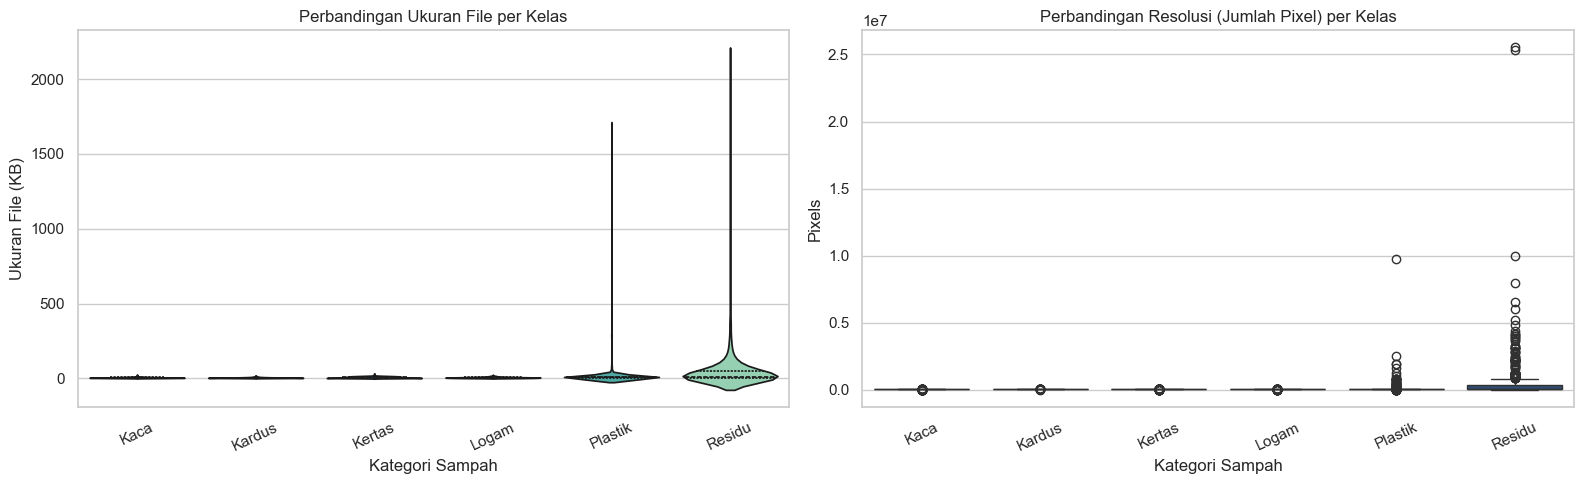

,median_file_size_kb,mean_file_size_kb,median_pixels,mean_aspect_ratio
class_label,,,,
Residu,8.06,53.00,50625.0,1.24
Plastik,7.68,12.67,50400.0,1.36
Kertas,7.40,8.30,50400.0,1.27
Logam,6.18,6.80,50400.0,1.22
Kaca,5.43,5.97,50401.0,1.09
Kardus,4.99,5.52,50437.0,1.25


In [ ]:
q2_stats = (
    clean_df.groupby("class_label")
    .agg(
        n_images=("file_name", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_file_size_kb=("file_size_kb", "median"),
        mean_file_size_kb=("file_size_kb", "mean"),
        iqr_file_size_kb=("file_size_kb", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        median_pixels=("pixels", "median"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
    )
    .sort_values("median_file_size_kb", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.violinplot(
    data=clean_df, x="class_label", y="file_size_kb", inner="quartile", palette="mako", ax=axes[0]
 )
axes[0].set_title("Sebaran Ukuran File per Kelas")
axes[0].set_xlabel("Kategori Sampah")
axes[0].set_ylabel("Ukuran File (KB)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean_df, x="class_label", y="pixels", palette="crest", ax=axes[1])
axes[1].set_title("Sebaran Resolusi (Jumlah Pixel) per Kelas")
axes[1].set_xlabel("Kategori Sampah")
axes[1].set_ylabel("Pixels")
axes[1].tick_params(axis="x", rotation=25)

sampled_df = clean_df.sample(min(3000, len(clean_df)), random_state=42)
sns.scatterplot(
    data=sampled_df,
    x="width",
    y="height",
    hue="class_label",
    alpha=0.5,
    s=22,
    ax=axes[2],
)
axes[2].set_title("Pola Dimensi Gambar (Sample)")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")
axes[2].legend(title="Kelas", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

spread_size = q2_stats["median_file_size_kb"].max() - q2_stats["median_file_size_kb"].min()
spread_pixels = q2_stats["median_pixels"].max() - q2_stats["median_pixels"].min()

print("Ringkasan perbedaan karakteristik gambar antar kategori:")
print(f"- Rentang median ukuran file antarkelas: {spread_size:.2f} KB")
print(f"- Rentang median jumlah pixel antarkelas: {spread_pixels:,.0f} pixel")
print("- IQR ukuran file yang tinggi menandakan variansi internal kelas lebih besar.")

display(q2_stats.round(2))

**Insight:**
- Pertanyaan pertama: distribusi gambar memang tidak seimbang. Terlihat ada kelas yang dominan dan ada yang jumlahnya jauh lebih sedikit.
- Pertanyaan kedua: ukuran file dan dimensi gambar antar kategori tidak sama, jadi preprocessing perlu dibuat konsisten dan tetap adaptif.
- Saran: pakai resize + normalisasi untuk semua data, lalu tambah augmentasi/class weight khusus untuk kelas yang datanya sedikit.

## Analisis Lanjutan (Opsional)

In [ ]:
# Analisis opsional: simulasi bobot kelas untuk menangani class imbalance pada tahap modeling
class_count = clean_df["class_label"].value_counts().sort_index()
class_weight = (class_count.sum() / (len(class_count) * class_count)).round(4)

class_weight_df = pd.DataFrame(
    {
        "class_label": class_weight.index,
        "n_images": class_count.values,
        "suggested_class_weight": class_weight.values,
    }
).sort_values("suggested_class_weight", ascending=False)

display(class_weight_df)

,class_label,n_images,suggested_class_weight
1,Kardus,624,1.8734
5,Residu,1006,1.1620
0,Kaca,1110,1.0532
3,Logam,1210,0.9661
4,Plastik,1257,0.9300
2,Kertas,1807,0.6469


## Conclusion

- Pertanyaan 1 (distribusi dan ketidakseimbangan): jumlah gambar per kategori tidak seimbang. Kategori mayoritas dan minoritas memiliki gap yang jelas, sehingga perlu penanganan imbalance pada tahap training.
- Pertanyaan 2 (karakteristik gambar): dimensi dan ukuran file menunjukkan variasi antarkategori, sehingga preprocessing tidak cukup hanya generik, perlu pipeline yang konsisten (resize, normalisasi) dan adaptif pada kelas minoritas (augmentasi/class weight).